## 0 · Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = "viridis"
print("Libraries loaded ✓")


Libraries loaded ✓


In [2]:
import os

DATA_DIR = ""

def p(name):
    return os.path.join(DATA_DIR, name)

post_sentiment         = pd.read_csv(p("post_sentiment.csv"))
meta                   = pd.read_csv(p("meta.csv"))
person_sentiment       = pd.read_csv(p("person_sentiment.csv"))
context_sentiment      = pd.read_csv(p("context_sentiment.csv"))
person_context_df      = pd.read_csv(p("person_context_sentiment.csv"))


post_sentiment = post_sentiment.rename(columns={"sentiment": "overall_sentiment"})


dataset = post_sentiment.merge(meta, on="post_id")


import ast
for label_col, prefix in [("person_labels", "person_"), ("context_labels", "context_")]:
    def safe_parse(x):
        try:
            lst = ast.literal_eval(x)
            return lst if isinstance(lst, list) else []
        except Exception:
            return []
    dataset[label_col + "_parsed"] = dataset[label_col].apply(safe_parse)

    all_vals = sorted({v for row in dataset[label_col + "_parsed"] for v in row})
    for val in all_vals:
        dataset[prefix + val] = dataset[label_col + "_parsed"].apply(lambda lst: int(val in lst))

PERSON_COLS  = [c for c in dataset.columns if c.startswith("person_")  and c not in ("person_labels", "person_labels_parsed")]
CONTEXT_COLS = [c for c in dataset.columns if c.startswith("context_") and c not in ("context_labels", "context_labels_parsed")]

print(f"Dataset shape : {dataset.shape}")
print(f"Person  cols  : {PERSON_COLS}")
print(f"Context cols  : {CONTEXT_COLS}")
dataset.head(3)


Dataset shape : (1709, 14)
Person  cols  : ['person_group', 'person_selfie', 'person_solo']
Context cols  : ['context_animal', 'context_everyday', 'context_other', 'context_outdoors', 'context_sport_gym']


,post_id,overall_sentiment,person_labels,context_labels,person_labels_parsed,person_group,person_selfie,person_solo,context_labels_parsed,context_animal,context_everyday,context_other,context_outdoors,context_sport_gym
0,100ih2i,0.559831,[],[],[],0,0,0,[],0,0,0,0,0
1,101elrt,0.564933,['solo'],['outdoors'],[solo],0,0,1,[outdoors],0,0,0,1,0
2,101x6uc,0.681500,['solo'],['animal'],[solo],0,0,1,[animal],1,0,0,0,0


## Figure 1 · Label Distribution

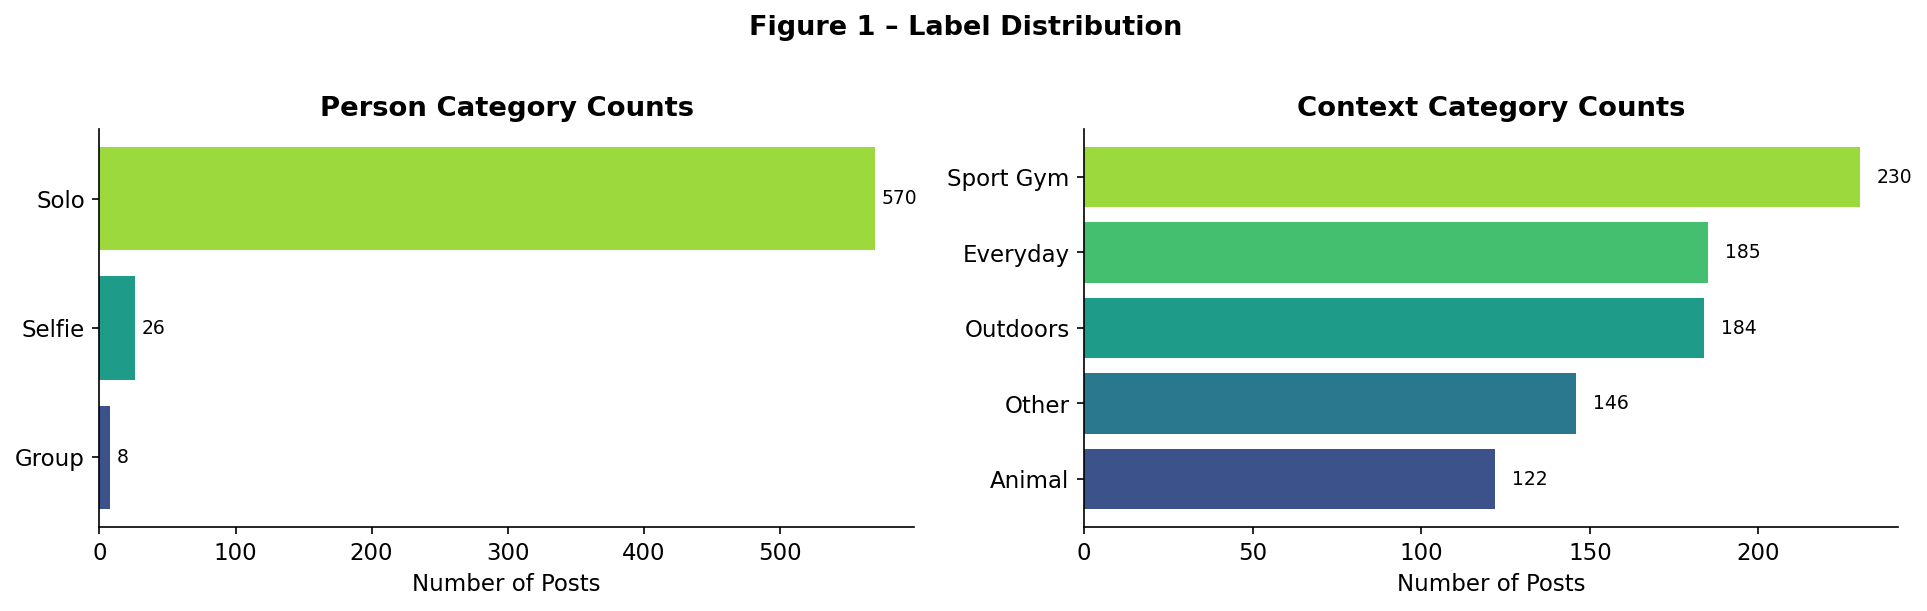

Saved → fig1_label_distribution.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cols, title in zip(
    axes,
    [PERSON_COLS, CONTEXT_COLS],
    ["Person Category Counts", "Context Category Counts"],
):
    counts = {c.replace("person_", "").replace("context_", "").replace("_", " ").title(): dataset[c].sum() for c in cols}
    counts = pd.Series(counts).sort_values(ascending=True)
    bars = ax.barh(counts.index, counts.values, color=plt.cm.viridis(np.linspace(0.25, 0.85, len(counts))))
    ax.set_xlabel("Number of Posts")
    ax.set_title(title, fontweight="bold")

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
                f"{int(val)}", va="center", fontsize=9)

fig.suptitle("Figure 1 – Label Distribution", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig1_label_distribution.png", bbox_inches="tight")
plt.show()
print("Saved → fig1_label_distribution.png")


## Figure 2 · Training Curves



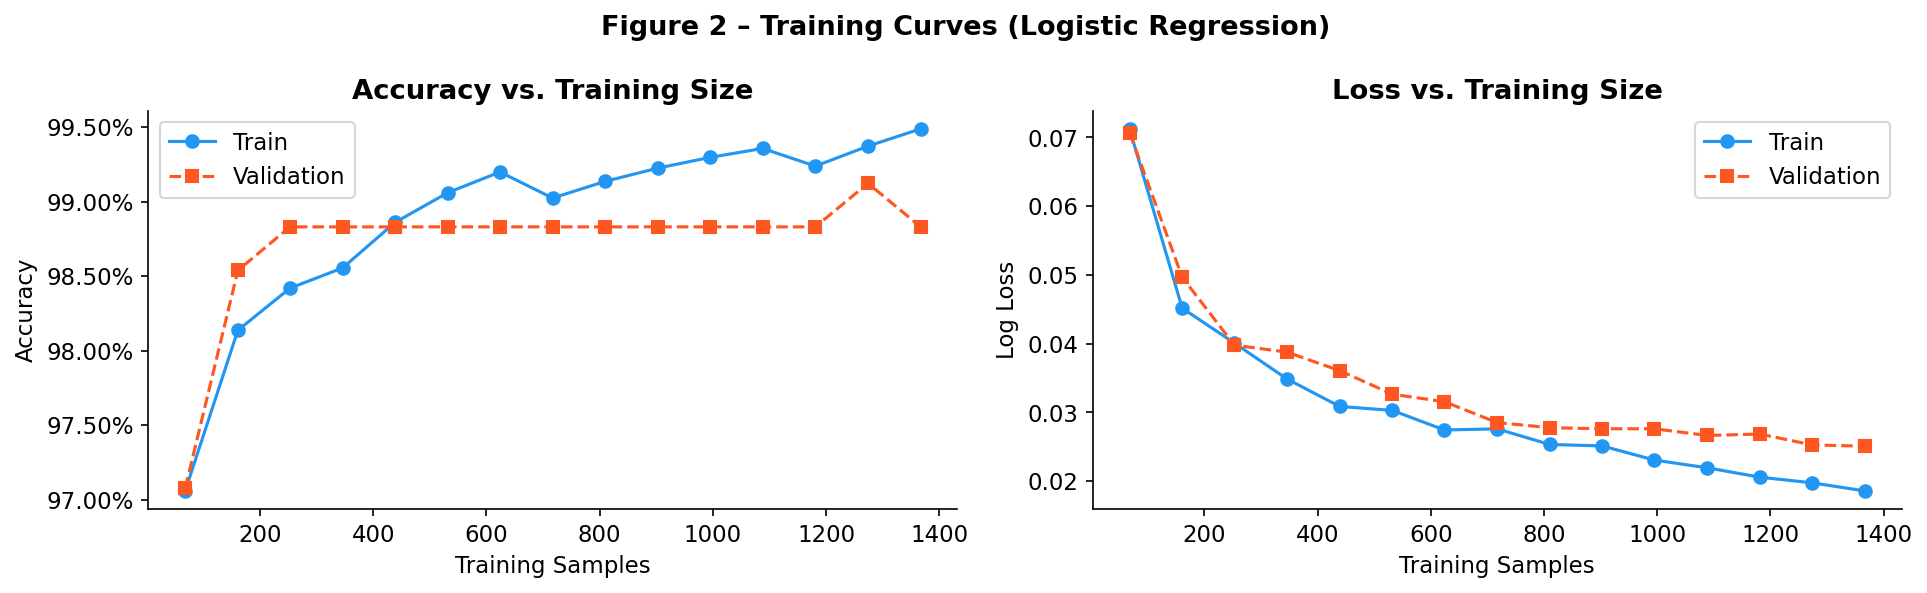

Final val accuracy : 0.988
Saved → fig2_training_curves.png


In [4]:
from sklearn.metrics import log_loss
from sklearn.model_selection import StratifiedShuffleSplit

feature_cols = [c for c in person_context_df.columns
                if c.startswith("person_") or c.startswith("context_")]

feature_cols = [c for c in feature_cols if c not in ("person_labels", "context_labels")]

X = person_context_df[["overall_sentiment"] + feature_cols].fillna(0).values
y = person_context_df["positive_feedback"].values

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_full = scaler.fit_transform(X_train_full)
X_test       = scaler.transform(X_test)

fracs   = np.linspace(0.05, 1.0, 15)
n_full  = len(X_train_full)

train_accs, val_accs   = [], []
train_losses, val_losses = [], []

for frac in fracs:
    n = max(10, int(frac * n_full))
    Xtr, ytr = X_train_full[:n], y_train_full[:n]
    clf = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
    clf.fit(Xtr, ytr)

    tr_prob = clf.predict_proba(Xtr)
    vl_prob = clf.predict_proba(X_test)

    train_accs.append((clf.predict(Xtr)  == ytr).mean())
    val_accs.append(  (clf.predict(X_test) == y_test).mean())
    train_losses.append(log_loss(ytr,   tr_prob))
    val_losses.append(  log_loss(y_test, vl_prob))

steps = (fracs * n_full).astype(int)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(steps, train_accs, "o-", label="Train", color="#2196F3")
ax1.plot(steps, val_accs,   "s--", label="Validation", color="#FF5722")
ax1.set_xlabel("Training Samples")
ax1.set_ylabel("Accuracy")
ax1.set_title("Accuracy vs. Training Size", fontweight="bold")
ax1.legend()
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax2.plot(steps, train_losses, "o-", label="Train", color="#2196F3")
ax2.plot(steps, val_losses,   "s--", label="Validation", color="#FF5722")
ax2.set_xlabel("Training Samples")
ax2.set_ylabel("Log Loss")
ax2.set_title("Loss vs. Training Size", fontweight="bold")
ax2.legend()

fig.suptitle("Figure 2 – Training Curves (Logistic Regression)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_training_curves.png", bbox_inches="tight")
plt.show()
print(f"Final val accuracy : {val_accs[-1]:.3f}")
print("Saved → fig2_training_curves.png")


## Figure 3 · Confusion Matrix



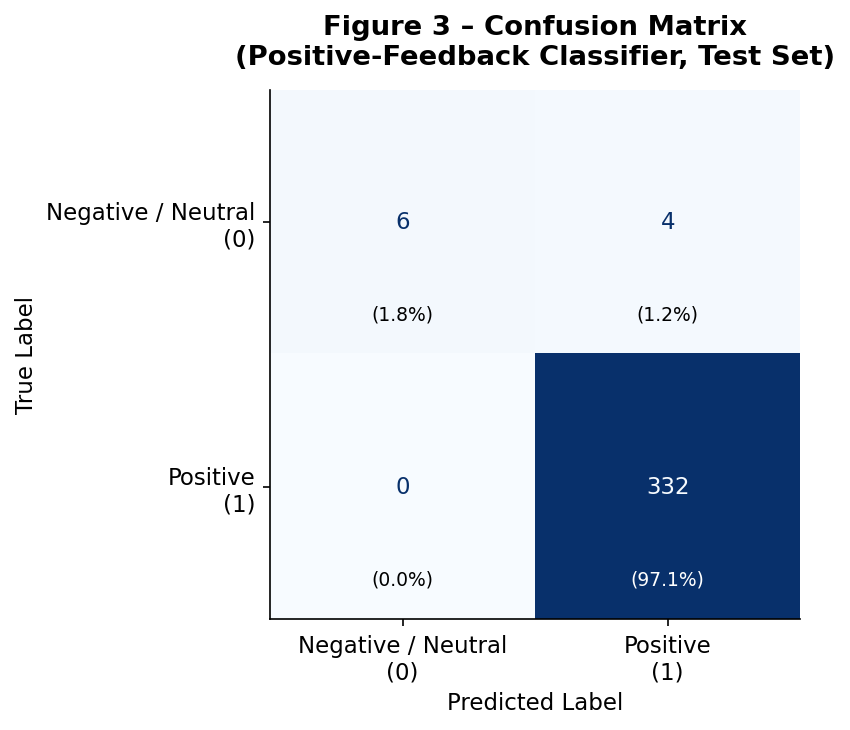

                  precision    recall  f1-score   support

Negative/Neutral       1.00      0.60      0.75        10
        Positive       0.99      1.00      0.99       332

        accuracy                           0.99       342
       macro avg       0.99      0.80      0.87       342
    weighted avg       0.99      0.99      0.99       342

Saved → fig3_confusion_matrix.png


In [5]:
clf_final = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
clf_final.fit(X_train_full, y_train_full)
y_pred = clf_final.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
labels = ["Negative / Neutral\n(0)", "Positive\n(1)"]

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=False, cmap="Blues")

total = cm.sum()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        pct = cm[i, j] / total * 100
        ax.text(j, i + 0.35, f"({pct:.1f}%)", ha="center", va="center",
                fontsize=9, color="white" if cm[i, j] > cm.max() / 2 else "black")

ax.set_title("Figure 3 – Confusion Matrix\n(Positive-Feedback Classifier, Test Set)",
             fontweight="bold", pad=12)
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)

plt.tight_layout()
plt.savefig("fig3_confusion_matrix.png", bbox_inches="tight")
plt.show()

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=["Negative/Neutral", "Positive"]))
print("Saved → fig3_confusion_matrix.png")


## Figure 4 · Sentiment by Person Category

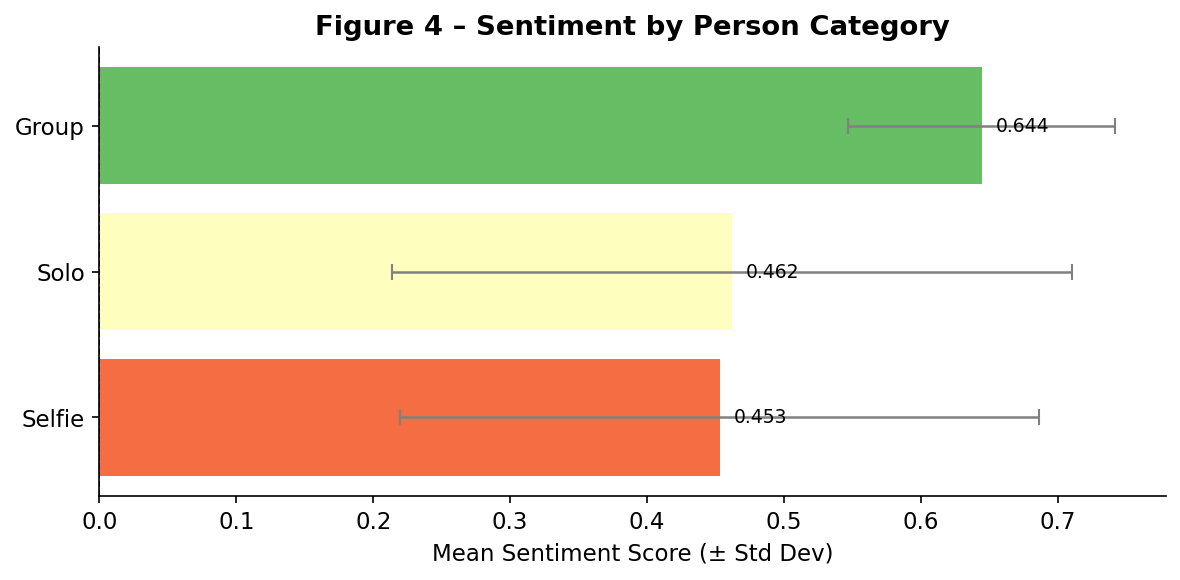

Saved → fig4_person_sentiment.png


In [9]:
ps_df = person_sentiment.copy().rename(columns={"Unnamed: 0": "category", "0": "mean_sentiment"})
ps_df = ps_df.dropna(subset=["mean_sentiment"])
ps_df["label"] = ps_df["category"].str.replace("person_", "").str.replace("_", " ").str.title()
ps_df = ps_df.sort_values("mean_sentiment")

std_map = {}
for col in [c for c in person_context_df.columns if c.startswith("person_") and c not in ("person_labels",)]:
    subset = person_context_df[person_context_df[col] == 1]["overall_sentiment"]
    if len(subset) > 0:
        std_map[col] = subset.std()

ps_df["std"] = ps_df["category"].map(std_map).fillna(0)

fig, ax = plt.subplots(figsize=(8, 4))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(ps_df)))
bars = ax.barh(ps_df["label"], ps_df["mean_sentiment"],
               xerr=ps_df["std"], color=colors,
               error_kw=dict(ecolor="grey", capsize=4, lw=1.2))

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Sentiment Score (± Std Dev)")
ax.set_title("Figure 4 – Sentiment by Person Category", fontweight="bold")

for bar, val in zip(bars, ps_df["mean_sentiment"]):
    x = bar.get_width()
    ax.text(x + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig4_person_sentiment.png", bbox_inches="tight")
plt.show()
print("Saved → fig4_person_sentiment.png")


## Figure 5 · Sentiment by Context Category

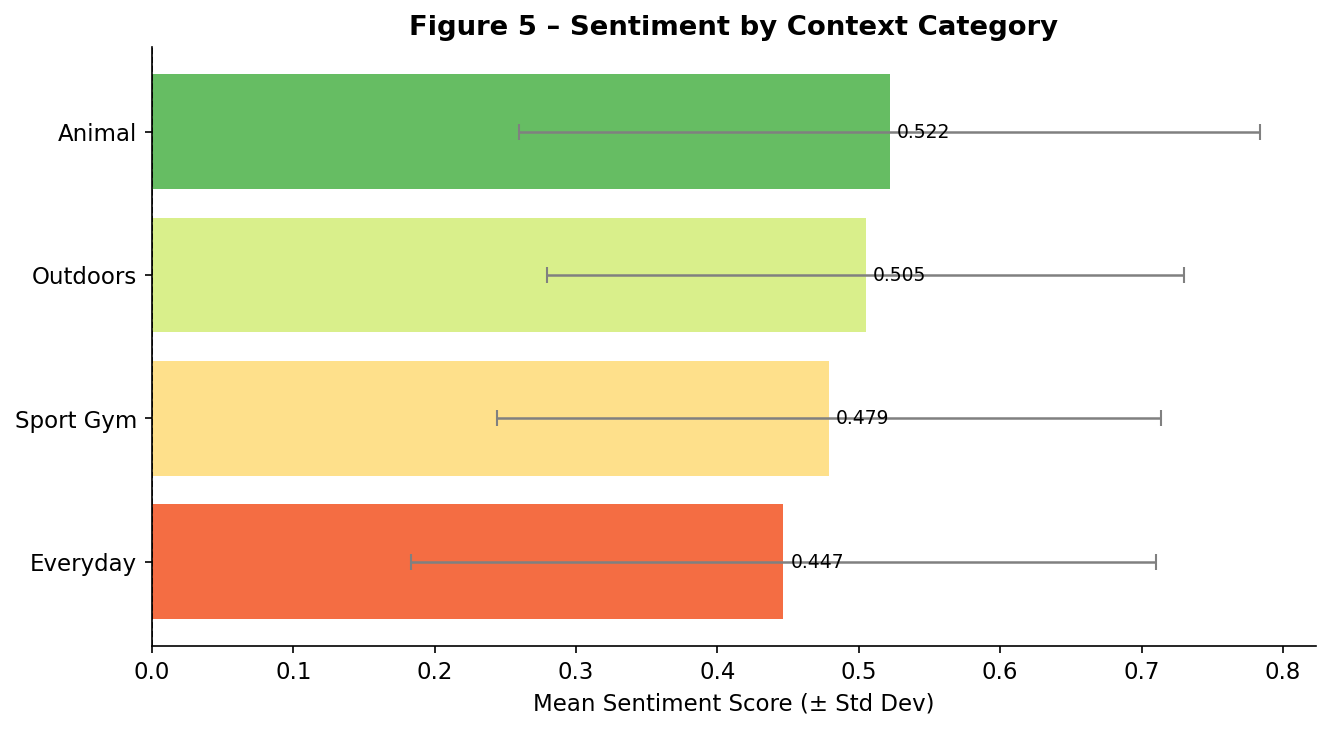

Saved → fig5_context_sentiment.png


In [10]:
cs_df = context_sentiment.copy().rename(columns={"Unnamed: 0": "category", "0": "mean_sentiment"})
cs_df = cs_df.dropna(subset=["mean_sentiment"])
cs_df["label"] = cs_df["category"].str.replace("context_", "").str.replace("_", " ").str.title()
cs_df = cs_df.sort_values("mean_sentiment")

std_map_c = {}
for col in [c for c in person_context_df.columns if c.startswith("context_") and c not in ("context_labels",)]:
    subset = person_context_df[person_context_df[col] == 1]["overall_sentiment"]
    if len(subset) > 0:
        std_map_c[col] = subset.std()

cs_df["std"] = cs_df["category"].map(std_map_c).fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(cs_df)))
bars = ax.barh(cs_df["label"], cs_df["mean_sentiment"],
               xerr=cs_df["std"], color=colors,
               error_kw=dict(ecolor="grey", capsize=4, lw=1.2))

ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean Sentiment Score (± Std Dev)")
ax.set_title("Figure 5 – Sentiment by Context Category", fontweight="bold")

for bar, val in zip(bars, cs_df["mean_sentiment"]):
    x = bar.get_width()
    ax.text(x + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig5_context_sentiment.png", bbox_inches="tight")
plt.show()
print("Saved → fig5_context_sentiment.png")


## Figure 6 · Person × Context Heatmap



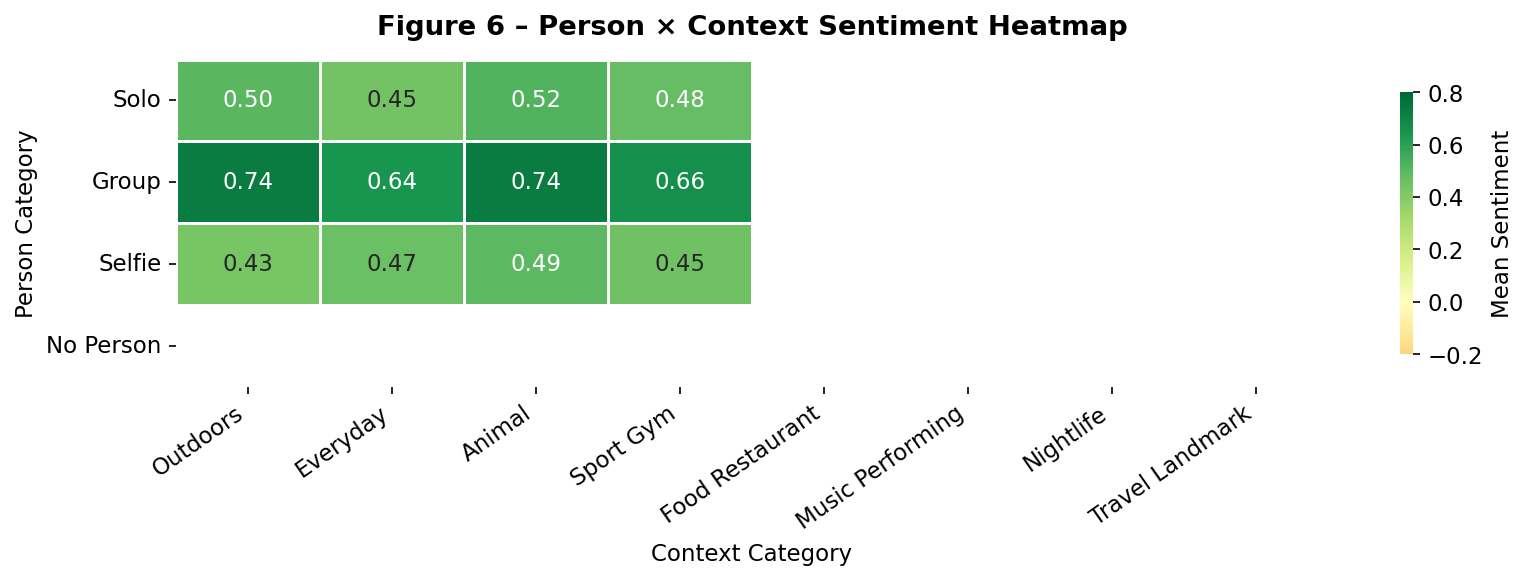

Saved → fig6_person_context_heatmap.png


In [11]:
pcdf = person_context_df.copy()

p_cols = [c for c in pcdf.columns if c.startswith("person_") and c not in ("person_labels",)]
c_cols = [c for c in pcdf.columns if c.startswith("context_") and c not in ("context_labels",)]

heatmap_data = pd.DataFrame(index=p_cols, columns=c_cols, dtype=float)

for pc in p_cols:
    for cc in c_cols:
        mask = (pcdf[pc] == 1) & (pcdf[cc] == 1)
        if mask.sum() > 0:
            heatmap_data.loc[pc, cc] = pcdf.loc[mask, "overall_sentiment"].mean()
        else:
            heatmap_data.loc[pc, cc] = np.nan

heatmap_data.index   = [i.replace("person_",  "").replace("_", " ").title() for i in heatmap_data.index]
heatmap_data.columns = [c.replace("context_", "").replace("_", " ").title() for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(
    heatmap_data.astype(float),
    ax=ax,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Mean Sentiment", "shrink": 0.8},
    mask=heatmap_data.isna(),
    vmin=-0.2, vmax=0.8,
)
ax.set_title("Figure 6 – Person × Context Sentiment Heatmap", fontweight="bold", pad=12)
ax.set_xlabel("Context Category")
ax.set_ylabel("Person Category")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("fig6_person_context_heatmap.png", bbox_inches="tight")
plt.show()
print("Saved → fig6_person_context_heatmap.png")
